# 03 — Krigeage ordinaire (baseline géostatistique)

Ce notebook met en œuvre le **premier pipeline complet** de
reconstruction de la carte probabiliste :

1. Simuler un champ et placer 20 capteurs uniformes (chacun retourne une
   probabilité de présence dans `[0, 1]`, fraction de positifs sur 50
   mesures temporelles).
2. Estimer un variogramme empirique sur ces observations probabilistes.
3. Krigeage ordinaire pour prédire ``p̂`` partout sur la grille.
4. Calculer les métriques (AUC, Brier, log-loss, MAE/RMSE) en comparant à
   la vérité terrain simulée (présence binaire et probabilité).
5. Visualiser : carte vraie, carte prédite, carte d'erreur, carte
   d'incertitude.

In [1]:
import logging
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from aphid_spatial.evaluation.metrics import calibration_curve_data, evaluate_all
from aphid_spatial.methods.geostatistics import OrdinaryKrigingIndicator
from aphid_spatial.simulation import (
    Field,
    FieldConfig,
    SensorConfig,
    place_sensors,
    simulate_field,
)
from aphid_spatial.visualization.maps import plot_summary

logging.basicConfig(level=logging.INFO, format="%(name)s | %(message)s")
FIG_DIR = Path("../outputs/figures")
RES_DIR = Path("../outputs/results")
FIG_DIR.mkdir(parents=True, exist_ok=True)
RES_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
data_path = Path("../data/simulated/field_default.npz")
if data_path.exists():
    field = Field.load(data_path)
else:
    field = simulate_field(FieldConfig(seed=42))

readings = place_sensors(
    field, SensorConfig(n_sensors=20, placement="uniform", n_observations=50, seed=2024)
)
print(f"capteurs : {readings.coords.shape[0]}")
print(f"obs : min={readings.obs.min():.3f}, mean={readings.obs.mean():.3f}, max={readings.obs.max():.3f}")
print(f"prob_local (réelle) : mean={readings.prob_local.mean():.3f}")

aphid_spatial.simulation.sensors | place_sensors: uniform, n=20, obs_mean=0.242, prob_local_mean=0.241


capteurs : 20
obs : min=0.060, mean=0.242, max=0.580
prob_local (réelle) : mean=0.241


## Variogramme empirique sur les observations

Avec 20 capteurs continus dans `[0, 1]`, le variogramme est plus stable
qu'en version binaire — chaque capteur fournit une information graduée
plutôt qu'un simple 0/1. ``pykrige`` l'estime et l'ajuste automatiquement
(modèle exponentiel par défaut).

In [3]:
method = OrdinaryKrigingIndicator(variogram_model="exponential", n_lags=8)
method.fit(readings, field)
if method._kriger is not None:
    print("variogram_model_parameters :", method._kriger.variogram_model_parameters)
else:
    print("Fallback : prédiction constante")

aphid_spatial.methods.geostatistics | OK fit OK : n=20, model=exponential, nlags=8, params=[3.74962951e-02 2.20760068e+02 3.05149521e-07]


variogram_model_parameters : [3.74962951e-02 2.20760068e+02 3.05149521e-07]


In [4]:
p_pred = method.predict_proba(field.coords)
sigma = method.predict_uncertainty(field.coords)

results = evaluate_all(field.presence, p_pred, p_true=field.prob)
for k, v in results.items():
    print(f"{k:>16} : {v:.4f}")

         auc_roc : 0.6721
          auc_pr : 0.3792
           brier : 0.1698
        log_loss : 0.5173
 prevalence_true : 0.2393
 prevalence_pred : 0.2560
        mae_prob : 0.1051
       rmse_prob : 0.1425


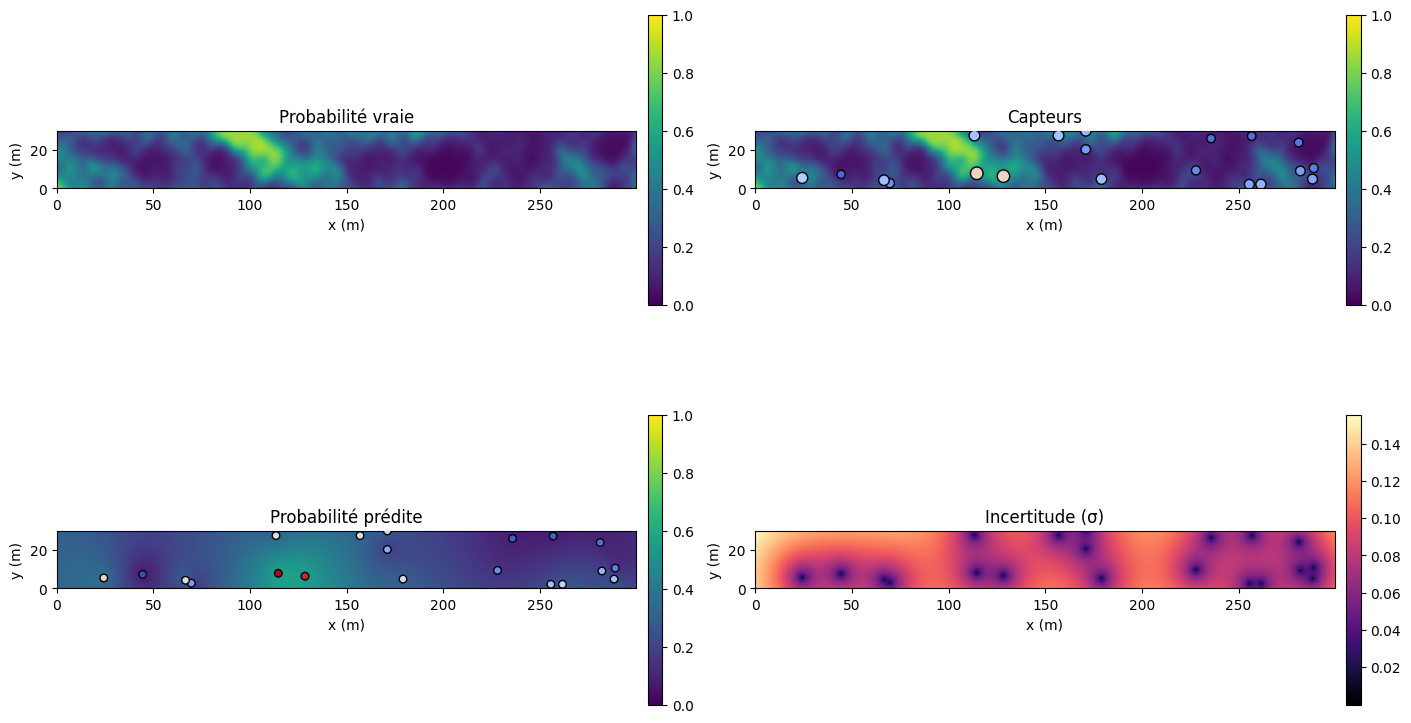

In [5]:
fig = plot_summary(field, readings, p_pred, sigma=sigma)
fig.savefig(FIG_DIR / "03_geostatistics_summary.png", dpi=150)
plt.show()

## Courbe de calibration (reliability diagram)

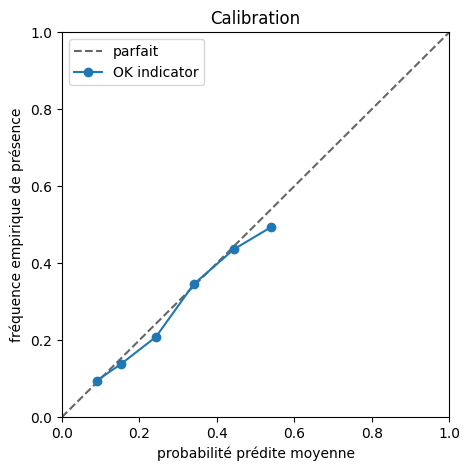

In [6]:
calib = calibration_curve_data(field.presence, p_pred, n_bins=10)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 1], [0, 1], "k--", alpha=0.6, label="parfait")
valid = calib["count"] > 0
ax.plot(calib["mean_pred"][valid], calib["frac_pos"][valid], "o-", label="OK indicator")
ax.set_xlabel("probabilité prédite moyenne")
ax.set_ylabel("fréquence empirique de présence")
ax.set_title("Calibration")
ax.legend()
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
fig.savefig(FIG_DIR / "03_geostatistics_calibration.png", dpi=150)
plt.show()

## Sauvegarde des métriques

In [7]:
import pandas as pd

row = {"method": method.name, "placement": readings.config.placement, "n_sensors": readings.config.n_sensors, **results}
df = pd.DataFrame([row])
out_path = RES_DIR / "03_geostatistics_metrics.csv"
df.to_csv(out_path, index=False)
print(f"Métriques sauvegardées : {out_path}")
df

Métriques sauvegardées : ..\outputs\results\03_geostatistics_metrics.csv


,method,placement,n_sensors,auc_roc,auc_pr,brier,log_loss,prevalence_true,prevalence_pred,mae_prob,rmse_prob
0,ordinary_kriging_indicator,uniform,20,0.672099,0.379204,0.169846,0.517349,0.23929,0.255963,0.105062,0.142466
